In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
from datasets import load_dataset
import re
import string
from wordcloud import WordCloud
import tiktoken
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from collections import Counter
import math
import random
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from huggingface_hub import login, HfApi
import gradio as gr
from sklearn.model_selection import train_test_split

In [2]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [6]:
texts = dataset["train"].shuffle(seed=42).select(range(10000))["text"]
full_text = "\n".join(texts)

In [7]:
print(full_text)

 Continuous , short @-@ arc , high pressure xenon arc lamps have a color temperature closely approximating noon sunlight and are used in solar simulators . That is , the chromaticity of these lamps closely approximates a heated black body radiator that has a temperature close to that observed from the Sun . After they were first introduced during the 1940s , these lamps began replacing the shorter @-@ lived carbon arc lamps in movie projectors . They are employed in typical 35mm , IMAX and the new digital projectors film projection systems , automotive HID headlights , high @-@ end " tactical " flashlights and other specialized uses . These arc lamps are an excellent source of short wavelength ultraviolet radiation and they have intense emissions in the near infrared , which is used in some night vision systems . 

 Field Marshal Antonio José de Sucre is portrayed as an intimate friend of the General . The historical Antonio José de Sucre , the Field Marshal of Ayacucho , had been the 

Generating Word Cloud...


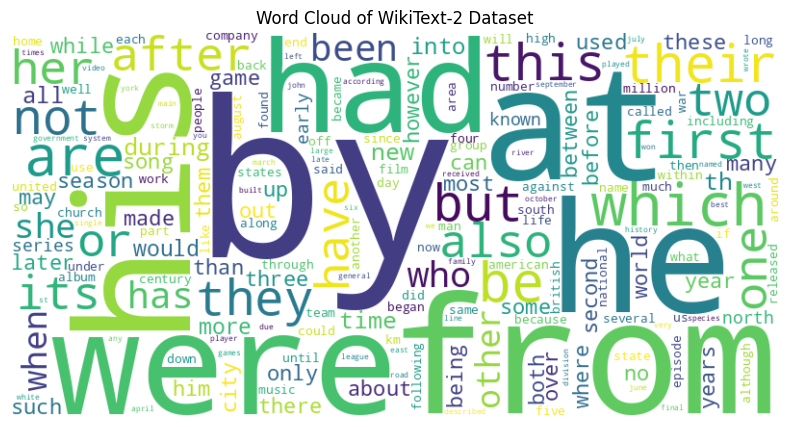


Generating Top 20 Words Bar Chart...


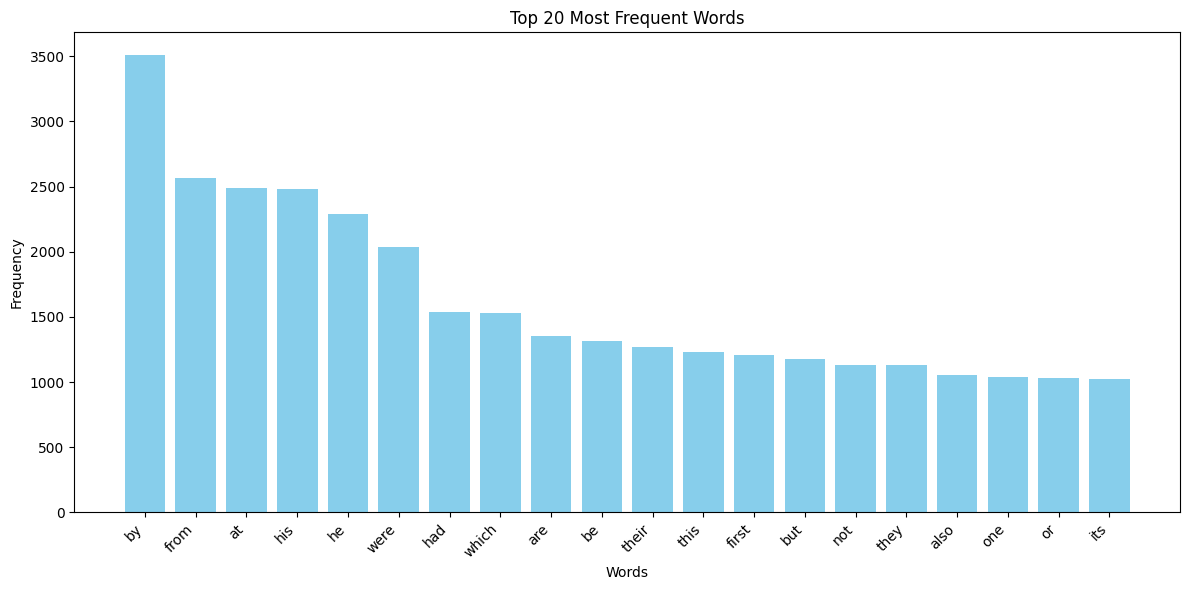

In [8]:
clean_text = full_text.lower()

clean_text = re.sub(r'[^a-z\s]', '', clean_text)

words = clean_text.split()

stopwords = set(['the', 'a', 'an', 'is', 'it', 'of', 'and', 'to', 'in', 'that', 'was', 'as', 'with', 'for', 'on'])
filtered_words = [word for word in words if len(word) > 1 and word not in stopwords]

word_counts = Counter(filtered_words)

print("Generating Word Cloud...")
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of WikiText-2 Dataset')
plt.show()

print("\nGenerating Top 20 Words Bar Chart...")
top_n = 20
top_words = word_counts.most_common(top_n)

if top_words:
    labels, values = zip(*top_words)

    plt.figure(figsize=(12, 6))
    plt.bar(labels, values, color='skyblue')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title(f'Top {top_n} Most Frequent Words')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No words found after filtering to generate a bar chart.")

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
full_text = clean_text(full_text)

In [11]:
full_text = f"<sos> {full_text} <eos>"

In [12]:
with open("chat_data.txt", "w", encoding="utf-8") as f:
    f.write(full_text)

In [13]:
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(
    vocab_size=5000,
    special_tokens=[
        "[UNK]",
        "<sos>",
        "<eos>"
    ]
)

In [14]:
tokenizer.train(['chat_data.txt'], trainer)

In [15]:
tokenizer.save("minigpt_tokenizer.json")

In [16]:
encoded = tokenizer.encode(
    "<sos> hello world <eos>"
)

print(encoded.tokens)
print(encoded.ids)

['<sos>', 'hel', 'lo', 'world', '<eos>']
[1, 1061, 643, 972, 2]


In [17]:
tokenizer = Tokenizer.from_file(
    "minigpt_tokenizer.json"
)

In [18]:
with open("chat_data.txt", "r", encoding="utf-8") as f:
    full_text = f.read()

In [19]:
encoded_data = tokenizer.encode(full_text)

token_ids = encoded_data.ids

In [20]:
print(token_ids[:50])

[1, 1302, 677, 1271, 505, 7, 925, 3340, 2221, 505, 7, 16, 827, 23, 722, 5, 2768, 3817, 1882, 533, 2774, 941, 690, 497, 1831, 1134, 506, 574, 811, 493, 4931, 1026, 558, 2484, 553, 509, 494, 519, 564, 2299, 623, 508, 958, 16, 827, 23, 1882, 533, 2774, 854]


In [21]:
data_tensor = tf.constant(token_ids, dtype=tf.int32)

In [22]:
block_size = 128

In [23]:
X = []
Y = []

for i in range(len(token_ids) - block_size):

    x = token_ids[i:i+block_size]
    y = token_ids[i+1:i+block_size+1]

    X.append(x)
    Y.append(y)

In [24]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, Y_val))
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [25]:
vocab_size = tokenizer.get_vocab_size()
block_size = 128
n_embd = 256
n_head = 4
n_layer = 6
dropout = 0.1

In [26]:
token_embedding = layers.Embedding(
    input_dim=vocab_size,
    output_dim=n_embd
)

position_embedding = layers.Embedding(
    input_dim=block_size,
    output_dim=n_embd
)

In [ ]:
class SelfAttention(layers.Layer):
  def __init__(self):
    super().__init__()
    self.attention = layers.MultiHeadAttention(
        num_heads=n_head,
        key_dim=n_embd // n_head,
        dropout=dropout
    )
    self.proj = layers.Dense(n_embd)
    self.dropout_layer = layers.Dropout(dropout)
    self.ln = layers.LayerNormalization()

  def call(self, x):
    attn_output = self.attention(
        x,
        x,
        use_causal_mask=True
    )
    attn_output = self.dropout_layer(attn_output)
    return self.ln(x + attn_output)


class FeedForward(layers.Layer):

    def __init__(self):

        super().__init__()

        self.net = keras.Sequential([
            layers.Dense(4 * n_embd, activation="gelu"),
            layers.Dense(n_embd),
            layers.Dropout(dropout)
        ])

    def call(self, x):

        return self.net(x)


class Block(layers.Layer):
  def __init__(self):
    super().__init__()

    self.ln1 = layers.LayerNormalization()
    self.atten = SelfAttention()
    self.ln2 = layers.LayerNormalization()
    self.ffn = FeedForward()

  def call(self, x):
    attn_output = self.atten(self.ln1(x))
    x = x + attn_output

    ffn_output = self.ffn(self.ln2(x))
    x = x + ffn_output

    return x


class MiniGPT(keras.Model):

    def __init__(self):

        super().__init__()

        self.token_embedding = layers.Embedding(
            vocab_size,
            n_embd
        )

        self.position_embedding = layers.Embedding(
            block_size,
            n_embd
        )

        self.blocks = [
            Block()
            for _ in range(n_layer)
        ]

        self.ln_f = layers.LayerNormalization()

        self.lm_head = layers.Dense(vocab_size)

    def call(self, idx):

        B = tf.shape(idx)[0]
        T = tf.shape(idx)[1]

        tok_emb = self.token_embedding(idx)

        pos = tf.range(T)

        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)

        logits = self.lm_head(x)

        return logits


model = MiniGPT()

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4
    ),
    loss=loss_fn
)

model.fit(
    train_dataset,
    epochs=3,
    validation_data=val_dataset
)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'self_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'self_attention_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'self_attention_2', however the la

15615/15615 ━━━━━━━━━━━━━━━━━━━━ 1410s 88ms/step - loss: 1.6265 - val_loss: 0.3265
Epoch 2/3
15615/15615 ━━━━━━━━━━━━━━━━━━━━ 1362s 87ms/step - loss: 0.2691 - val_loss: 0.2401
Epoch 3/3
11272/15615 ━━━━━━━━━━━━━━━━━━━━ 5:52 81ms/step - loss: 0.2245

In [ ]:
model.save_weights("minigpt.keras")

In [ ]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=50,
    temperature=1.0
):

    tokens = tokenizer.encode(prompt).ids

    for _ in range(max_new_tokens):

        x = tf.constant([tokens[:,][-128:]] if isinstance(tokens, np.ndarray) else [tokens[-128:]])

        logits = model(x)

        logits = logits[:, -1, :]

        logits = logits / temperature

        probs = tf.nn.softmax(logits)

        next_token = tf.random.categorical(
            tf.math.log(probs),
            num_samples=1
        )

        next_token = int(next_token[0][0])

        tokens.append(next_token)

        if tokenizer.id_to_token(next_token) == "<eos>":
            break

    text = tokenizer.decode(tokens)

    return text

In [ ]:
output = generate_text(
    model,
    tokenizer,
    "japanese",
    max_new_tokens=1000,
    temperature=0.1
)

print(output)